# Teleoperaattorin kuukausittaiset verkon KPI:t: datankäytön pylväät sekä ARPU- ja asiakaspoistumaviivat (PROC GBARLINE)

## Yhteenveto

Tämä muistikirja käyttää **PROC GBARLINEa** yhdistämään kuukausittaisen mobiilidatan käytön pystypylväskaavion ARPU:n, asiakaspoistuman ja tukipyyntöjen päällekkäin piirrettyihin viivakaavioihin — klassinen "kaksiakselinen" KPI-hallintapaneeli, jonka teleoperaattorin analyytikko rakentaa nähdäkseen, muuttuuko kasvava käyttö todella tuotoksi ja asiakaspysyvyydeksi. Se generoi synteettisiä tilaajakohtaisia tietueita koodin sisällä ja käyttää sitten BAR- ja LINE-lauseita alaryhmien, mukautettujen oikeanpuoleisten akseleiden, viitesymbolien ja selitteiden kanssa.

## Tietolähteet

**Aineisto: `telco_kpi`** — synteettisiä tilaaja-kuukausi-tietueita (4 kuukautta x 3 liittymätyyppiä x 8 tilaajaa = 96 riviä), generoitu koodin sisällä komennolla `call streaminit(20260531)`. Paneeli pidetään 96 rivissä, jotta se mahtuu mukavasti lisensoimattoman tilan 100 havainnon rajaan, jättäen jokaisen kuukauden ja liittymätyypin täysin täytetyksi.

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|--------------|
| `month`  | Merkki | Kalenterikuukauden nimike (tammi–huhti) |
| `plan`   | Merkki | Liittymätyyppi: Ennakko, Jälkilasku, Perhe |
| `data_gb`| Num  | Kuukausittain kulutettu mobiilidata, Gt (gamma-jakautunut, lievällä kausivaihtelulla ja hitaalla kasvulla) |
| `arpu`   | Num  | Keskimääräinen tulo käyttäjää kohden, USD (nousee liittymätyypin ja kuukausien myötä) |
| `churn`  | Num  | Kuukausittainen asiakaspoistumalippu (0/1, Bernoulli; korkeampi kauden alussa ja halvemmissa liittymätyypeissä) |
| `tickets`| Num  | Avatut tukipyynnöt (Poisson-lukumäärä) |

# Teleoperaattorin kuukausittaiset verkon KPI:t PROC GBARLINElla

Teleoperaattorit elävät ja kuolevat kourallisen kuukausittaisten KPI-mittareiden varassa: kuinka paljon **dataa** tilaajat kuluttavat, kuinka paljon **ARPU:ta** (keskimääräinen tulo käyttäjää kohden) tämä kulutus tuottaa, kuinka moni asiakas **poistuu**, ja kuinka suuri **tukipyyntökuorma** on tämän kaiken takana. Nämä mittarit elävät hyvin eri asteikoilla — gigatavuja, dollareita ja pieniä lukumääriä — joten niiden piirtäminen yhdelle vasteakselille kätkisi tarinan.

`PROC GBARLINE` on rakennettu juuri tähän: se piirtää pystysuoran **pylväs**kaavion vasenta akselia vasten ja lisää sen päälle yhden tai useamman **viiva**kaavion itsenäistä oikeaa akselia vasten. Tässä muistikirjassa rakennamme käyttö-vs-tuotto-hallintapaneelin ja lisäämme sitten asteittain liittymätason alaryhmiä, mukautetun oikean akselin ja moniviivaisia päällekkäisyyksiä.

## Vaihe 1 — Synteettisen tilaaja-kuukausi-datan generointi

Alla oleva DATA-vaihe luo realistisen paneelin: 4 kuukautta (tammi–huhti) kolmella liittymätyypillä (Ennakko, Jälkilasku, Perhe) kahdeksalla tilaajalla kutakin, yhteensä 96 riviä. Kylvämme satunnaislukugeneraattorin komennolla `call streaminit` toistettavuuden vuoksi ja arvomme jokaisen KPI:n toimialalle sopivasta jakaumasta:

- **Datankäyttö** gamma-jakaumasta lievällä kausivaihtelulla ja hitaalla kuukausittaisella kasvulla.
- **ARPU** nousee liittymätyypin ja kuukausien myötä, normaalikohinalla.
- **Asiakaspoistuma** Bernoulli-lippuna, joka on korkeampi kauden alussa ja halvemmissa liittymätyypeissä.
- **Tukipyynnöt** Poisson-lukumäärinä, hieman raskaampina alussa.

Ulkoisia tiedostoja ei lueta — kaikki on itsenäistä, ja 96 rivin paneeli pysyy lisensoimattoman tilan 100 havainnon rajan sisällä, joten jokainen kuukausi ja liittymätyyppi renderöityy.

In [1]:
TIEDOT telco_kpi;
    CALL streaminit(20260531);
    PITUUS month $6 plan $12;
    TAULUKKO mname[4] $6 _temporary_
        ('Tammi' 'Helmi' 'Maalis' 'Huhti');
    TEE mi = 1 ASTI 4;
        month = mname[mi];
        /* lievä kausivaihtelu ja hidas datan kasvu */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        TEE plan_i = 1 ASTI 3;
            JOS plan_i = 1 NIIN plan = 'Ennakko';
            MUUTEN JOS plan_i = 2 NIIN plan = 'Jälkilasku';
            MUUTEN plan = 'Perhe';
            TEE rep = 1 ASTI 8;
                /* kuukausittain kulutettu mobiilidata (Gt) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* keskimääräinen tulo käyttäjää kohden ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* kuukausittainen asiakaspoistumalippu, korkeampi vuoden alussa */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* avatut tukipyynnöt */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                TULOSTE;
            LOPPU;
        LOPPU;
    LOPPU;
    POISTA mi plan_i rep season mname:;
SUORITA;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Vaihe 2 — Ydinhallintapaneeli: käyttöpylväät + ARPU-viiva

Tämä on kanoninen `GBARLINE`-kaava. `BAR`-lause piirtää keskimääräisen kuukausittaisen datankäytön (`SUMVAR=data_gb TYPE=mean`), ja yksittäinen `LINE`-lause lisää keskimääräisen ARPU:n oikealle akselille (`STAT=mean TYPE=join`). Kytkemme ODS-grafiikan päälle ja annamme kaaviolle kaksirivisen otsikon. `COUTLINE=` ja `WIDTH=` siistivät pylväät.

                                      Kuukausittainen mobiilidatan käyttö ja ARPU                                       
                                       Synteettiset teleoperaattorin verkon KPI:t                                       




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Kuukausittainen mobiilidatan käyttö ja ARPU.
NOTE: Option TITLE2 changed to Synteettiset teleoperaattorin verkon KPI:t.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


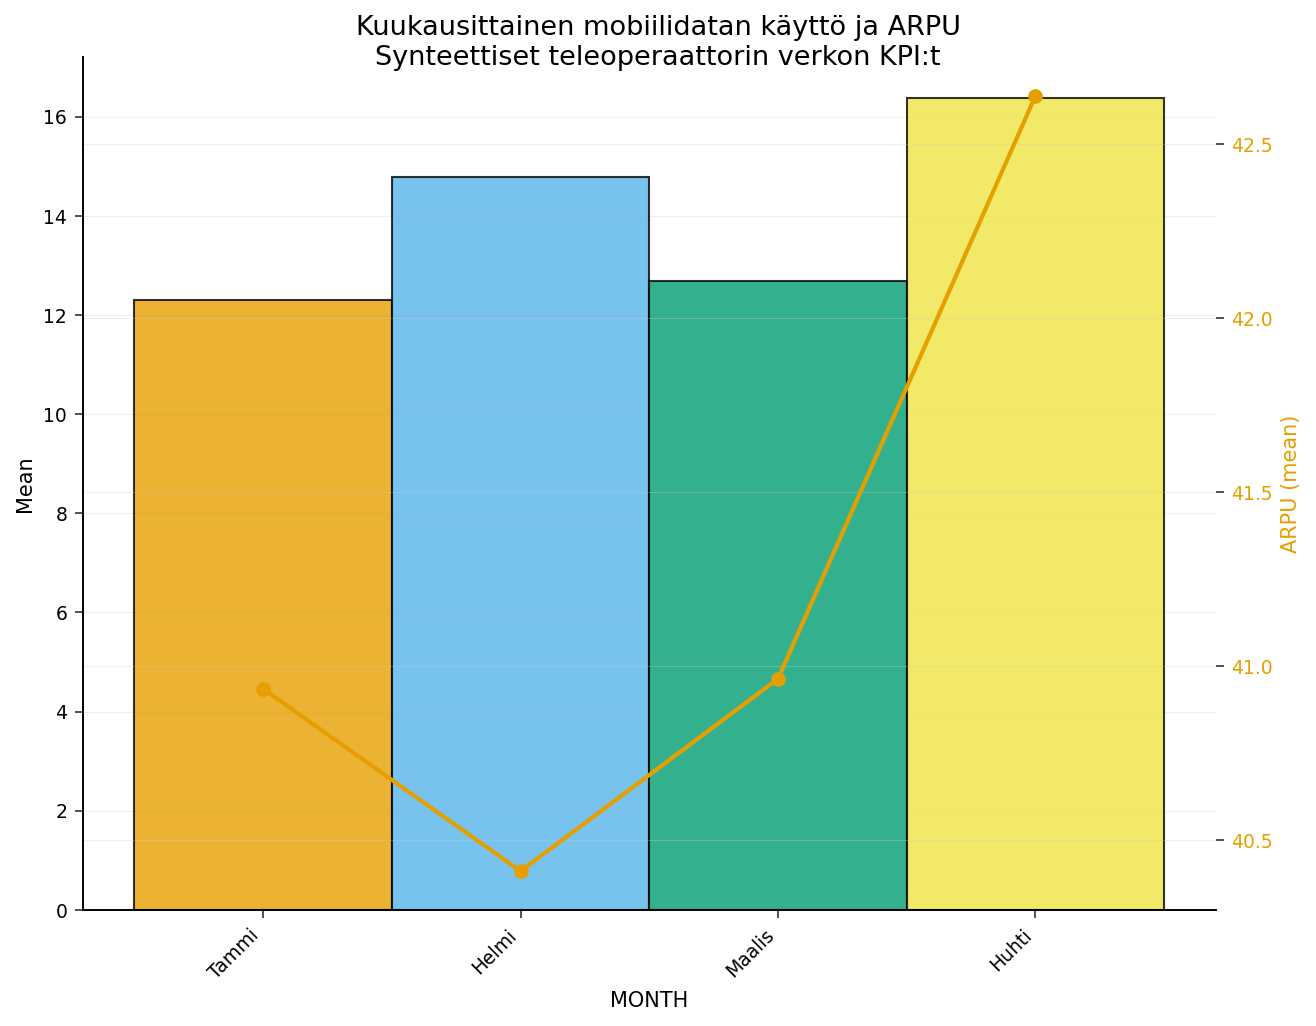

In [2]:
ODS GRAPHICS ON;
OTSIKKO "Kuukausittainen mobiilidatan käyttö ja ARPU";
title2 "Synteettiset teleoperaattorin verkon KPI:t";

PROSEDUURI gbarline TIEDOT=telco_kpi;
    NIMIKE data_gb="Data (Gt)" arpu="ARPU (USD)" month="Kuukausi";
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
SUORITA;

## Vaihe 3 — Käytön jakaminen liittymätyypeittäin, asiakaspoistuman lisääminen

Korvaamalla `TYPE=mean` arvolla `TYPE=sum` ja lisäämällä `SUBGROUP=plan` kunkin kuukauden pylväs pinotaan liittymätyypeittäin, joten näemme, mikä segmentti ajaa kokonaisvolyymiä. Päälle piirretty `LINE` kuvaa nyt asiakaspoistumatapahtumien kuukausittaista **lukumäärää** piikkikaaviona (`STAT=sum TYPE=needle`) — pystysuoria piikkejä, jotka luetaan luontevasti diskreetteinä tapahtumalukumäärinä eivätkä sulavana trendinä.

                        Datavolyymi liittymätyypeittäin kuukausittaisen asiakaspoistuman kanssa                         
                                       Synteettiset teleoperaattorin verkon KPI:t                                       




NOTE: Option TITLE changed to Datavolyymi liittymätyypeittäin kuukausittaisen asiakaspoistuman kanssa.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


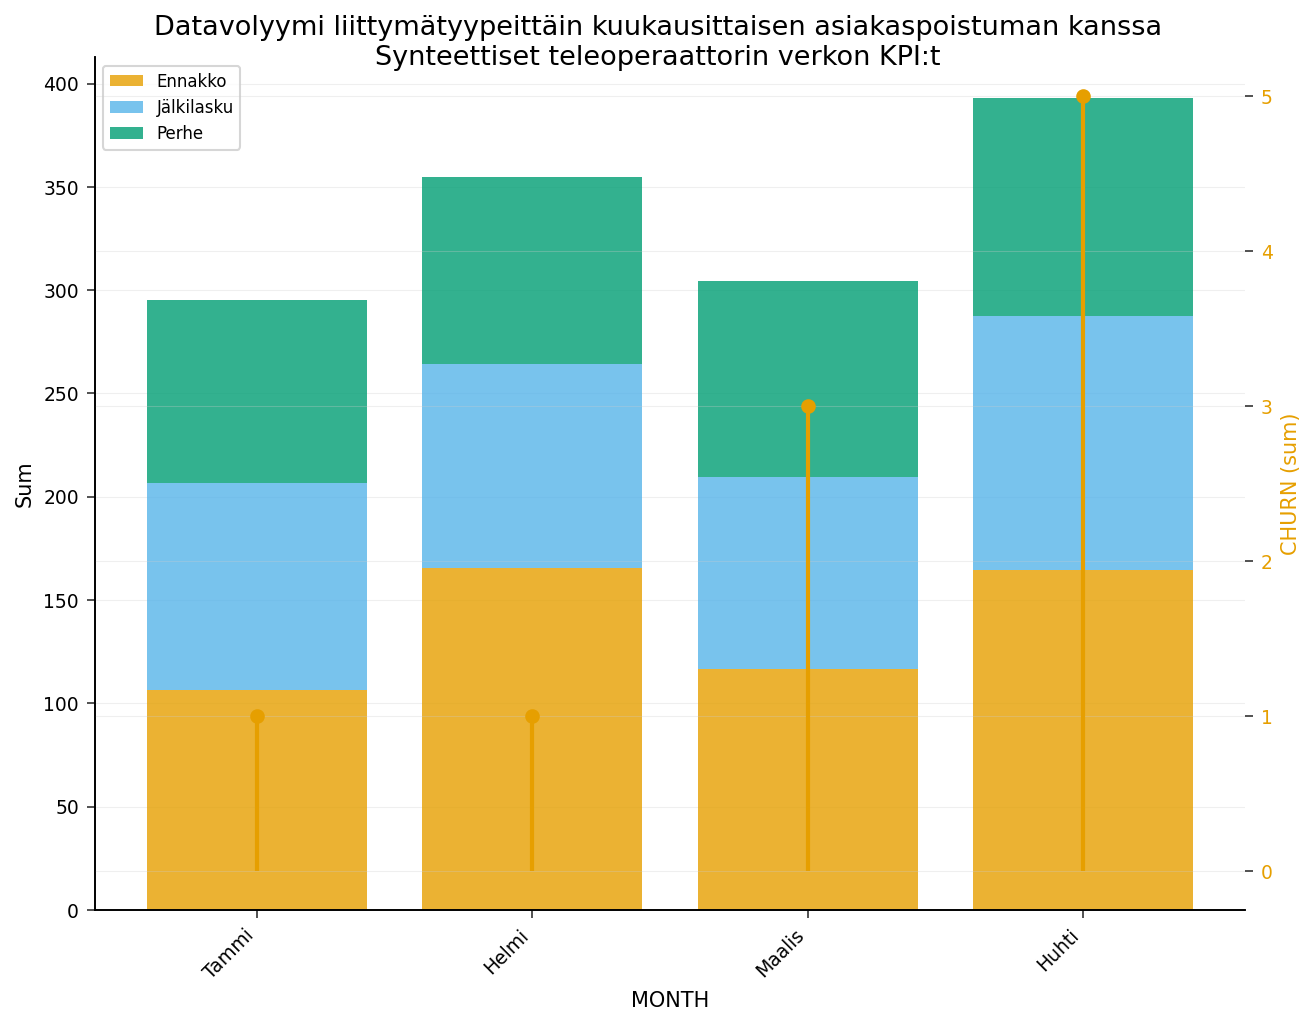

In [3]:
OTSIKKO "Datavolyymi liittymätyypeittäin kuukausittaisen asiakaspoistuman kanssa";

PROSEDUURI gbarline TIEDOT=telco_kpi;
    NIMIKE data_gb="Data (Gt)" churn="Asiakaspoistuma" month="Kuukausi" plan="Liittymätyyppi";
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
SUORITA;

## Vaihe 4 — Oikean akselin ja viivamerkin hallinta

Julkaisukelpoista kaaviota varten kiinnitämme kaavion (oikean) akselin kiinteälle vaihteluvälille `AXIS`-määrittelyllä ja nimeämme sen, ja sidomme sen sitten viivaan `RAXIS=axis2`-määrityksellä. `SYMBOL`-määrittely antaa ARPU-viivalle punaisen pisteviivamerkin. Näytämme myös pylväiden summat kunkin pylvään yläpuolella käyttäen `OUTSIDE=sum`.

                                Kokonaiskäyttö (pylväät) vs. keskimääräinen ARPU (viiva)                                
                                       Synteettiset teleoperaattorin verkon KPI:t                                       




NOTE: Option TITLE changed to Kokonaiskäyttö (pylväät) vs. keskimääräinen ARPU (viiva).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


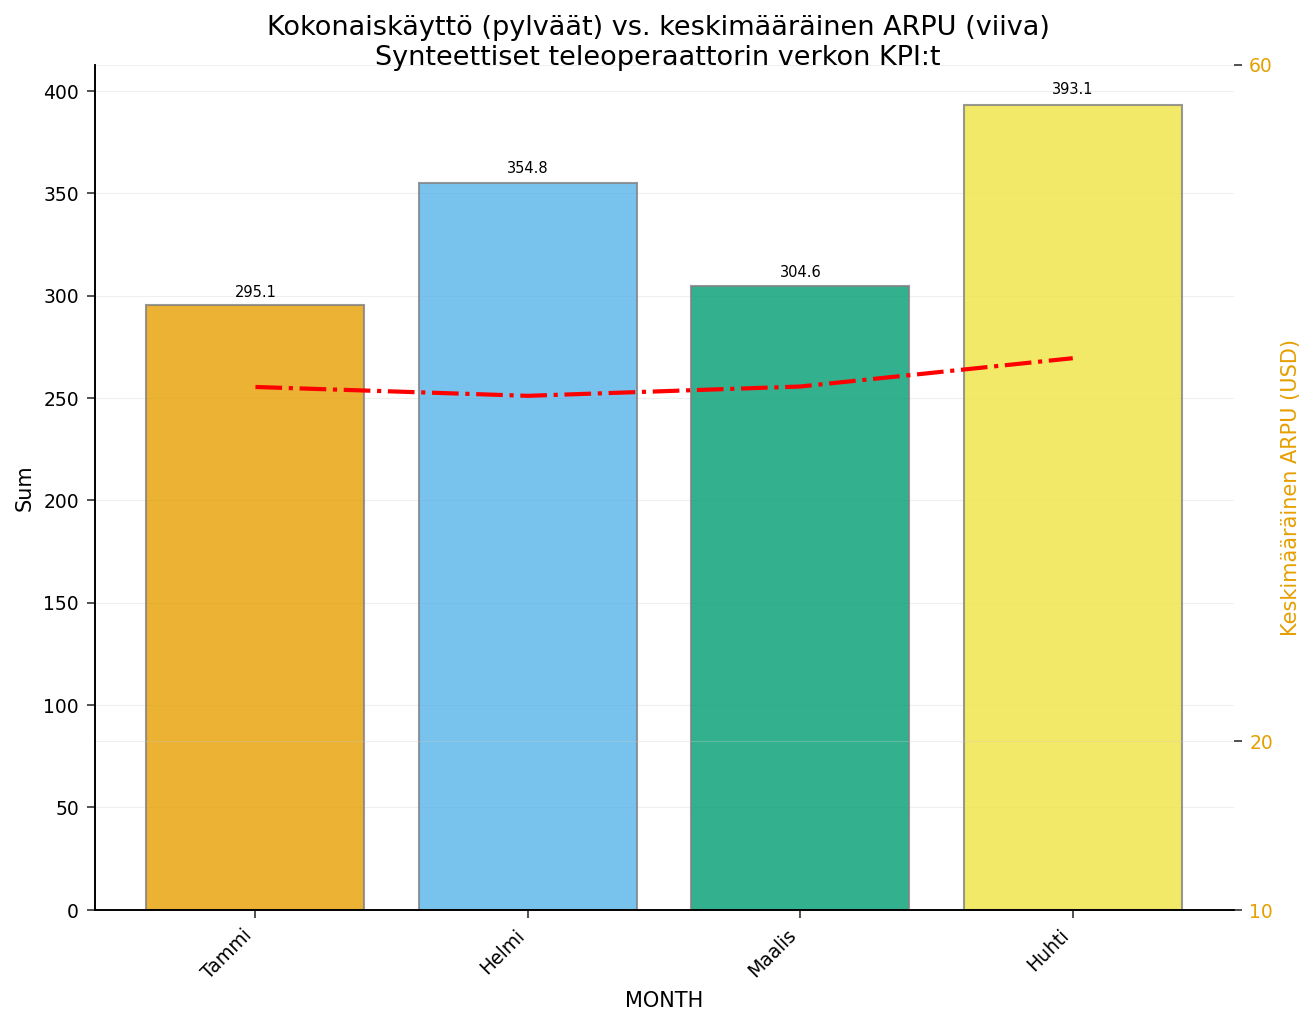

In [4]:
OTSIKKO "Kokonaiskäyttö (pylväät) vs. keskimääräinen ARPU (viiva)";

PROSEDUURI gbarline TIEDOT=telco_kpi;
    NIMIKE data_gb="Data (Gt)" arpu="ARPU (USD)" month="Kuukausi";
    axis2 ORDER=(20 ASTI 60 MUKAAN 10) NIMIKE=("Keskimääräinen ARPU (USD)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
SUORITA;

## Vaihe 5 — Useita viivapäällekkäisyyksiä mukautetulla selitteellä

`GBARLINE` hyväksyy useamman kuin yhden `LINE`-lauseen, joten voimme verrata kahta operatiivista signaalia käyttöpylväitä vasten samanaikaisesti: keskimääräisiä tukipyyntöjä (`type=join`) ja kokonaisasiakaspoistumaa (`type=needle`). Alareunaan sijoitettu `LEGEND`-määrittely dokumentoi liittymätyyppien alaryhmät.

                                       Tukipyyntöjen ja asiakaspoistuman trendit                                        
                                       Synteettiset teleoperaattorin verkon KPI:t                                       




NOTE: Option TITLE changed to Tukipyyntöjen ja asiakaspoistuman trendit.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


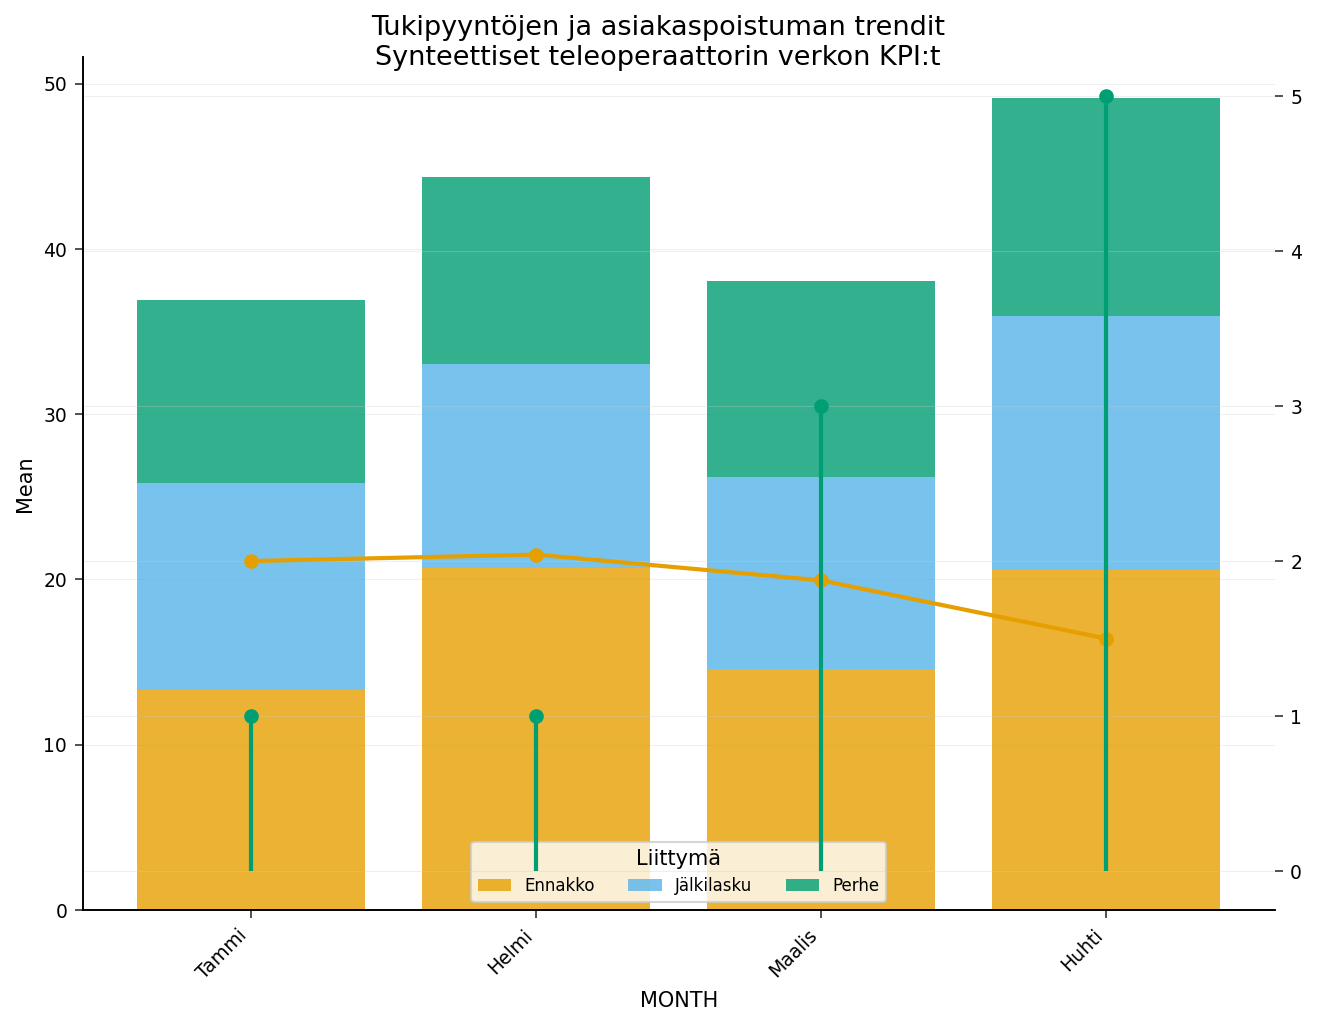

In [5]:
OTSIKKO "Tukipyyntöjen ja asiakaspoistuman trendit";

PROSEDUURI gbarline TIEDOT=telco_kpi;
    NIMIKE data_gb="Data (Gt)" tickets="Tukipyynnöt" churn="Asiakaspoistuma"
          month="Kuukausi" plan="Liittymätyyppi";
    legend1 NIMIKE=("Liittymä") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
SUORITA;

ODS GRAPHICS OFF;

## Tulosten tulkinta

Tammi–huhtikuun ikkunassa hallintapaneeli kertoo johdonmukaisen teleoperaattoritarinan. **Datankäyttö** (pylväät) vaihtelee kuukaudesta toiseen mutta trendi on nouseva, huipentuen **huhtikuussa** — keskimääräinen käyttö nousee noin 12,3 Gt:sta tammikuussa 16,4 Gt:iin huhtikuussa (Vaihe 2), ja kokonaisvolyymi 295 Gt:sta 393 Gt:iin (`OUTSIDE=sum`-merkinnät Vaiheessa 4). **ARPU-viiva** laskee hieman helmikuussa ja nousee sitten omaan huhtikuun huippuunsa lähelle 42,6 dollaria, joten operaattori rahallistaa yhä enemmän lisäkulutusta sen sijaan, että antaisi sen ilmaiseksi — Vaiheen 4 oikea akseli on kiinnitetty välille 20–60 dollaria, jotta tuo liike pysyy luettavana.

Liittymätyypeittäin pinotut näkymät (Vaiheet 3 ja 5) paljastavat segmenttijännitteen, joka määrittää ennakkomaksuvaltaiset operaattorit. **Ennakko** (oranssi kaista) kuljettaa eniten gigatavuja kaikkiaan — noin 553 Gt neljän kuukauden aikana verrattuna 415 Gt:hen Jälkilaskulle ja 380 Gt:hen Perheelle — mutta tuottaa silti **matalimman** keskimääräisen tulon käyttäjää kohden (noin 36 dollaria, verrattuna 41 dollariin Jälkilaskulle ja 47 dollariin Perheelle). **Asiakaspoistumapiikit** vahvistavat, missä asiakaspysyvyysriski on: poistumatapahtumat keskittyvät Ennakko- ja Jälkilasku-liittymätyyppeihin (4 tapahtumaa kumpaankin ikkunan aikana) ja pysyvät kevyempinä Perheessä (2), ja ne kasvavat kohti huhtikuuta tilaajakunnan ja käytön kasvaessa.

Vaihe 5 lisää tämän päälle operatiivisen kuorman: keskimääräiset **tukipyynnöt** ovat hieman raskaampia kauden alussa ja helpottuvat huhtikuuhun mennessä, kun taas asiakaspoistumapiikit huipentuvat myöhemmin — juuri sellainen signaali, jota asiakaspysyvyystiimi seuraa. Toiminnallisesti tulkinta on keskittää asiakaspysyvyyspanostukset **Ennakko**-tilaajiin, jotka kuluttavat nopeimmin kasvavaa datavolyymin siivua tuottaen samalla vähiten tuloja ja eniten asiakaspoistumaa.

`PROC GBARLINE` on tässä oikea työkalu juuri siksi, että se pitää gigatavuasteikon pylväät ja dollari-/lukumääräasteikon viivat itsenäisillä akseleilla, jolloin jokainen KPI voidaan lukea omilla ehdoillaan samalla kun ne jakavat kuukausittaisen aika-akselin.